In [10]:

from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.linalg import Vectors
from pyspark.sql import Row

# Initialisation
spark = SparkSession.builder \
    .appName("Ex6_KMeans") \
    .getOrCreate()

print("="*60)
print("EXERCICE 6: K-means sur kmeans_data.txt")
print("="*60)

# Chargement
lines = spark.sparkContext.textFile("kmeans_data.txt")

# Conversion
data = lines.map(lambda line: Row(features=Vectors.dense([float(x) for x in line.split()]))).toDF()

print("\nDonnées:")
data.show(5, truncate=False)

# K-means: k=3, maxIter=10
kmeans = KMeans().setK(3).setMaxIter(10).setSeed(1)
model = kmeans.fit(data)

print("\nCentres des clusters:")
for i, c in enumerate(model.clusterCenters()):
    print(f"Cluster {i}: {c}")

# Prédictions
pred = model.transform(data)
pred.show(10, truncate=False)

# Distribution
pred.groupBy("prediction").count().show()

# WSSSE
print(f"\nWSSE: {model.summary.trainingCost:.4f}")
print("\n✅ Terminé!")

EXERCICE 6: K-means sur kmeans_data.txt



Données:


+-------------+
|features     |
+-------------+
|[0.0,0.0,0.0]|
|[0.1,0.1,0.1]|
|[0.2,0.2,0.2]|
|[9.0,9.0,9.0]|
|[9.1,9.1,9.1]|
+-------------+
only showing top 5 rows




Centres des clusters:
Cluster 0: [9.1 9.1 9.1]
Cluster 1: [0.05 0.05 0.05]
Cluster 2: [0.2 0.2 0.2]
+-------------+----------+
|features     |prediction|
+-------------+----------+
|[0.0,0.0,0.0]|1         |
|[0.1,0.1,0.1]|1         |
|[0.2,0.2,0.2]|2         |
|[9.0,9.0,9.0]|0         |
|[9.1,9.1,9.1]|0         |
|[9.2,9.2,9.2]|0         |
+-------------+----------+

+----------+-----+
|prediction|count|
+----------+-----+
|         1|    2|
|         2|    1|
|         0|    3|
+----------+-----+


WSSE: 0.0750

✅ Terminé!


In [13]:


from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import split, col, avg
from pyspark.sql.types import DoubleType
import urllib.request

# Initialisation
spark = SparkSession.builder \
    .appName("Ex7_KMeans") \
    .getOrCreate()

print("="*60)
print("EXERCICE 7: K-means sur 3D_spatial_network.txt")
print("="*60)

# Téléchargement
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/00246/3D_spatial_network.txt"
local_path = "/tmp/3D_spatial_network.txt"

print("\nTéléchargement...")
urllib.request.urlretrieve(url, local_path)
print("✅ OK!")

# Chargement
df_raw = spark.read.text(local_path)
df_raw.show(5, truncate=False)

# Prétraitement
df_split = df_raw.withColumn("arr", split(col("value"), ","))

df_clean = df_split.select(
    col("arr").getItem(1).cast(DoubleType()).alias("x"),
    col("arr").getItem(2).cast(DoubleType()).alias("y"),
    col("arr").getItem(3).cast(DoubleType()).alias("z")
).filter(col("x").isNotNull())


print("\nDonnées 3D:")
df_clean.show(10)

# Vecteur features
assembler = VectorAssembler(inputCols=["x", "y", "z"], outputCol="features")
df_feat = assembler.transform(df_clean)

# K-means: k=3, maxIter=20
kmeans = KMeans().setK(3).setMaxIter(20).setSeed(1)
model = kmeans.fit(df_feat)

print("\nCentres 3D:")
for i, c in enumerate(model.clusterCenters()):
    print(f"Cluster {i}: x={c[0]:.4f}, y={c[1]:.4f}, z={c[2]:.4f}")

# Prédictions
pred = model.transform(df_feat)
pred.select("x", "y", "z", "prediction").show(15)

# Distribution
pred.groupBy("prediction").count().show()

# Stats
pred.groupBy("prediction").agg(
    avg("x").alias("moy_x"),
    avg("y").alias("moy_y"),
    avg("z").alias("moy_z")
).show()

print(f"\nWSSE: {model.summary.trainingCost:.4f}")
print(f"Itérations: {model.summary.numIter}")
print("\n✅ Terminé!")

EXERCICE 7: K-means sur 3D_spatial_network.txt

Téléchargement...
✅ OK!
+-----------------------------------------------+
|value                                          |
+-----------------------------------------------+
|144552912,9.3498486,56.7408757,17.0527715677876|
|144552912,9.3501884,56.7406785,17.614840244389 |
|144552912,9.3505485,56.7405445,18.08353563951  |
|144552912,9.3508058,56.7404845,18.2794652530352|
|144552912,9.3510534,56.7404863,18.4229736146099|
+-----------------------------------------------+
only showing top 5 rows


Données 3D:
+---------+----------+----------------+
|        x|         y|               z|
+---------+----------+----------------+
|9.3498486|56.7408757|17.0527715677876|
|9.3501884|56.7406785| 17.614840244389|
|9.3505485|56.7405445|  18.08353563951|
|9.3508058|56.7404845|18.2794652530352|
|9.3510534|56.7404863|18.4229736146099|
|9.3514747|56.7405022|19.1248885940143|
|9.3521273|56.7405585|19.5905926656897|
|9.3524201|56.7405974|19.6217636955693|



Centres 3D:
Cluster 0: x=9.6247, y=57.0413, z=29.4859
Cluster 1: x=9.7536, y=57.1205, z=8.4616
Cluster 2: x=9.9303, y=57.0456, z=59.4211
+---------+----------+----------------+----------+
|        x|         y|               z|prediction|
+---------+----------+----------------+----------+
|9.3498486|56.7408757|17.0527715677876|         1|
|9.3501884|56.7406785| 17.614840244389|         1|
|9.3505485|56.7405445|  18.08353563951|         1|
|9.3508058|56.7404845|18.2794652530352|         1|
|9.3510534|56.7404863|18.4229736146099|         1|
|9.3514747|56.7405022|19.1248885940143|         0|
|9.3521273|56.7405585|19.5905926656897|         0|
|9.3524201|56.7405974|19.6217636955693|         0|
|9.3525839| 56.740629|19.6599309194984|         0|
|9.3527255|56.7406626|19.4906695590218|         0|
|9.3530759|56.7408002|19.2302682047961|         0|
| 9.353404|56.7409042|18.2332801889404|         1|
|9.3537287|56.7409995|17.6008423536018|         1|
| 9.354179|56.7410594|17.6443793914607|       

+----------+------+
|prediction| count|
+----------+------+
|         1|230039|
|         2| 55425|
|         0|149410|
+----------+------+



+----------+-----------------+------------------+------------------+
|prediction|            moy_x|             moy_y|             moy_z|
+----------+-----------------+------------------+------------------+
|         1|9.753515282399079| 57.12052747051106|  8.46504513647802|
|         2|9.930403188396937| 57.04565261190434|59.428955305109696|
|         0|9.624797594312302|57.041282297558254|29.494112490670123|
+----------+-----------------+------------------+------------------+


WSSE: 22778278.2414
Itérations: 20

✅ Terminé!


In [ ]:
TP_3

In [2]:
# ============================================================================
# PROJET: Clustering de Profils de Patients
# Personnalisation Précise des Traitements Médicaux
# ============================================================================

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA, StringIndexer
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.functions import col, count, avg, stddev
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================================
# INITIALISATION SPARK
# ============================================================================

spark = SparkSession.builder \
    .appName("Clustering_Patients_Medical") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("="*80)
print("PROJET: CLUSTERING DE PROFILS DE PATIENTS")
print("="*80)

# ============================================================================
# 1. CHARGEMENT ET EXPLORATION DES DONNÉES
# ============================================================================

print("\n" + "="*80)
print("1. CHARGEMENT ET EXPLORATION DES DONNÉES")
print("="*80)

# Chargement du dataset (à adapter selon votre chemin)
df = spark.read.csv("insurance.csv", header=True, inferSchema=True)

print("\n📊 Schéma des données:")
df.printSchema()

print("\n📈 Aperçu des données (10 premières lignes):")
df.show(10)

print(f"\n📏 Nombre de lignes: {df.count()}")
print(f"📏 Nombre de colonnes: {len(df.columns)}")

print("\n📊 Statistiques descriptives:")
df.describe().show()

print("\n🔍 Vérification des valeurs manquantes:")
df.select([count(col(c)).alias(c) for c in df.columns]).show()


PROJET: CLUSTERING DE PROFILS DE PATIENTS

1. CHARGEMENT ET EXPLORATION DES DONNÉES

📊 Schéma des données:
root
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- children: integer (nullable = true)
 |-- smoker: string (nullable = true)
 |-- region: string (nullable = true)
 |-- charges: double (nullable = true)


📈 Aperçu des données (10 premières lignes):
+---+------+------+--------+------+---------+-----------+
|age|   sex|   bmi|children|smoker|   region|    charges|
+---+------+------+--------+------+---------+-----------+
| 19|female|  27.9|       0|   yes|southwest|  16884.924|
| 18|  male| 33.77|       1|    no|southeast|  1725.5523|
| 28|  male|  33.0|       3|    no|southeast|   4449.462|
| 33|  male|22.705|       0|    no|northwest|21984.47061|
| 32|  male| 28.88|       0|    no|northwest|  3866.8552|
| 31|female| 25.74|       0|    no|southeast|  3756.6216|
| 46|female| 33.44|       1|    no|southeast|  8240.5896|


In [3]:
# ============================================================================
# 2. PRÉTRAITEMENT DES DONNÉES
# ============================================================================

print("\n" + "="*80)
print("2. PRÉTRAITEMENT DES DONNÉES")
print("="*80)

# Encodage des variables catégorielles
print("\n🔄 Encodage des variables catégorielles...")

# Sex: male/female -> 0/1
indexer_sex = StringIndexer(inputCol="sex", outputCol="sex_indexed")
df = indexer_sex.fit(df).transform(df)

# Smoker: yes/no -> 0/1
indexer_smoker = StringIndexer(inputCol="smoker", outputCol="smoker_indexed")
df = indexer_smoker.fit(df).transform(df)

# Region: 4 régions -> 0/1/2/3
indexer_region = StringIndexer(inputCol="region", outputCol="region_indexed")
df = indexer_region.fit(df).transform(df)

print("✅ Encodage terminé!")

# Sélection des features numériques
feature_cols = ["age", "sex_indexed", "bmi", "children", "smoker_indexed", "region_indexed"]

# Assemblage des features
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_assembled = assembler.transform(df)

print(f"\n🔢 Features utilisées: {feature_cols}")

# Normalisation (centrage et réduction)
print("\n📐 Normalisation des données (StandardScaler)...")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", 
                        withMean=True, withStd=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

print("✅ Normalisation terminée!")

df_scaled.select("features_scaled").show(5, truncate=False)


2. PRÉTRAITEMENT DES DONNÉES

🔄 Encodage des variables catégorielles...
✅ Encodage terminé!

🔢 Features utilisées: ['age', 'sex_indexed', 'bmi', 'children', 'smoker_indexed', 'region_indexed']

📐 Normalisation des données (StandardScaler)...
✅ Normalisation terminée!
+-------------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                          |
+-------------------------------------------------------------------------------------------------------------------------+
|[-1.4382265049624725,1.0101410032223745,-0.45315056770302886,-0.9082740622237025,1.9698501029141982,0.48207811539617984] |
|[-1.5094010828978865,-0.9892209232739821,0.5094306199542413,-0.07873775146922173,-0.5072734287579795,-1.2875255016136615]|
|[-0.7976553035437455,-0.9892209232739821,0.3831635817095905,1.58033487003974,-0.5072734287579795,-1.2875255016


3. ANALYSE EN COMPOSANTES PRINCIPALES (PCA)

📊 Variance expliquée par composante:
  PC1: 20.79% (Cumulée: 20.79%)
  PC2: 18.19% (Cumulée: 38.98%)
  PC3: 17.21% (Cumulée: 56.19%)
  PC4: 15.88% (Cumulée: 72.07%)
  PC5: 15.45% (Cumulée: 87.52%)
  PC6: 12.48% (Cumulée: 100.00%)

✅ 3.a. Nombre d'axes pour conserver 70% d'information: 4
   Variance cumulée avec 4 composantes: 72.07%

📊 Graphique sauvegardé: pca_variance_explained.png


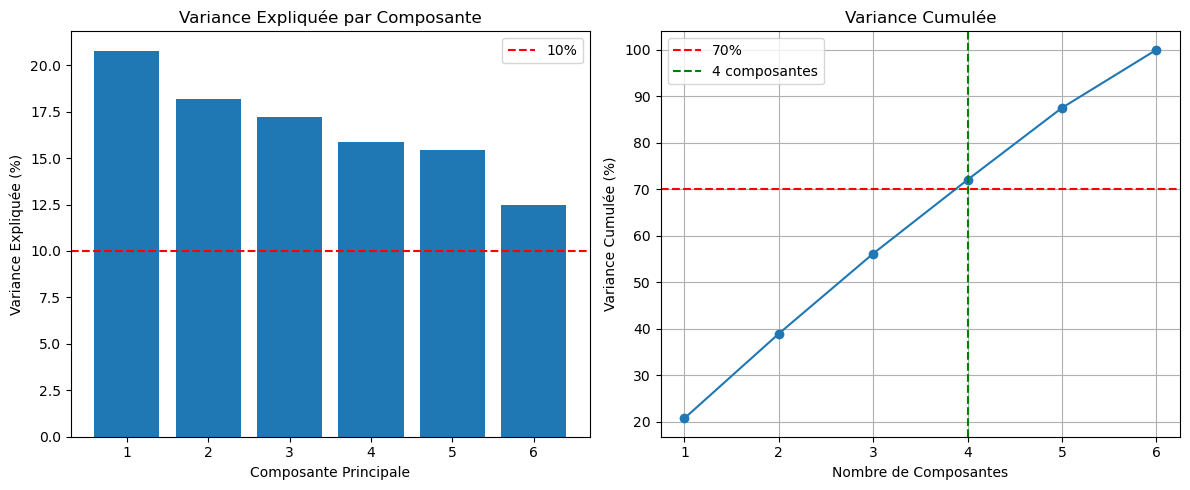

In [10]:
# ============================================================================
# 3. ANALYSE EN COMPOSANTES PRINCIPALES (PCA)
# ============================================================================

print("\n" + "="*80)
print("3. ANALYSE EN COMPOSANTES PRINCIPALES (PCA)")
print("="*80)

# PCA avec toutes les composantes
n_features = len(feature_cols)
pca_full = PCA(k=n_features, inputCol="features_scaled", outputCol="pca_features")
pca_model_full = pca_full.fit(df_scaled)

# Variance expliquée par chaque composante
explained_variance = pca_model_full.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

print("\n📊 Variance expliquée par composante:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"  PC{i+1}: {var*100:.2f}% (Cumulée: {cum_var*100:.2f}%)")

# 3.a. Nombre d'axes à retenir pour 70% de variance
n_components_70 = np.argmax(cumulative_variance >= 0.70) + 1
print(f"\n✅ 3.a. Nombre d'axes pour conserver 70% d'information: {n_components_70}")
print(f"   Variance cumulée avec {n_components_70} composantes: {cumulative_variance[n_components_70-1]*100:.2f}%")

# Visualisation de la variance expliquée
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, n_features+1), explained_variance*100)
plt.xlabel('Composante Principale')
plt.ylabel('Variance Expliquée (%)')
plt.title('Variance Expliquée par Composante')
plt.axhline(y=10, color='r', linestyle='--', label='10%')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, n_features+1), cumulative_variance*100, marker='o')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Cumulée (%)')
plt.title('Variance Cumulée')
plt.axhline(y=70, color='r', linestyle='--', label='70%')
plt.axvline(x=n_components_70, color='g', linestyle='--', label=f'{n_components_70} composantes')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique sauvegardé: pca_variance_explained.png")
plt.show()



3.b. INTERPRÉTATION DES DEUX PREMIERS AXES PRINCIPAUX

📊 Contributions des variables aux 2 premiers axes:

PC1 (Axe 1):
  age                 : -0.2688
  sex_indexed         :  0.1831
  bmi                 : -0.6946
  children            : -0.0988
  smoker_indexed      : -0.1401
  region_indexed      :  0.6184

PC2 (Axe 2):
  age                 : -0.5105
  sex_indexed         : -0.5609
  bmi                 : -0.1319
  children            : -0.0977
  smoker_indexed      :  0.6259
  region_indexed      : -0.0778

💡 INTERPRÉTATION:
PC1 - Premier axe principal:
  Variable dominante: bmi
  Cet axe représente principalement les caractéristiques liées à cette variable

PC2 - Deuxième axe principal:
  Variable dominante: smoker_indexed
  Cet axe capture la variabilité orthogonale au premier axe

3.c. VISUALISATION DES PATIENTS DANS LE PLAN PRINCIPAL

📊 Graphique sauvegardé: pca_patients_projection.png


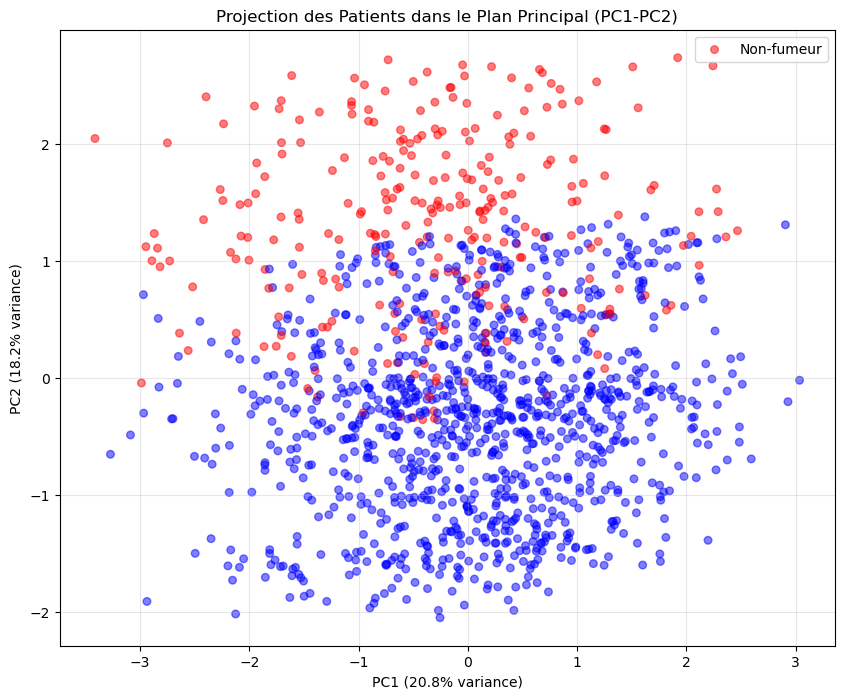

In [11]:
# 3.b. Interprétation des deux premiers axes
print("\n" + "="*80)
print("3.b. INTERPRÉTATION DES DEUX PREMIERS AXES PRINCIPAUX")
print("="*80)

# Extraction des composantes principales
pc_matrix = pca_model_full.pc.toArray()

print("\n📊 Contributions des variables aux 2 premiers axes:")
print("\nPC1 (Axe 1):")
for i, feature in enumerate(feature_cols):
    print(f"  {feature:20s}: {pc_matrix[i, 0]:7.4f}")

print("\nPC2 (Axe 2):")
for i, feature in enumerate(feature_cols):
    print(f"  {feature:20s}: {pc_matrix[i, 1]:7.4f}")

print("\n💡 INTERPRÉTATION:")
print("PC1 - Premier axe principal:")
idx_max_pc1 = np.argmax(np.abs(pc_matrix[:, 0]))
print(f"  Variable dominante: {feature_cols[idx_max_pc1]}")
print(f"  Cet axe représente principalement les caractéristiques liées à cette variable")

print("\nPC2 - Deuxième axe principal:")
idx_max_pc2 = np.argmax(np.abs(pc_matrix[:, 1]))
print(f"  Variable dominante: {feature_cols[idx_max_pc2]}")
print(f"  Cet axe capture la variabilité orthogonale au premier axe")

# 3.c. Visualisation des patients dans le plan principal
print("\n" + "="*80)
print("3.c. VISUALISATION DES PATIENTS DANS LE PLAN PRINCIPAL")
print("="*80)

# PCA avec 2 composantes pour visualisation
pca_2d = PCA(k=2, inputCol="features_scaled", outputCol="pca_2d")
pca_model_2d = pca_2d.fit(df_scaled)
df_pca_2d = pca_model_2d.transform(df_scaled)

# Conversion en Pandas pour visualisation
df_pca_pandas = df_pca_2d.select("pca_2d", "smoker").toPandas()
pca_values = np.array([row.toArray() for row in df_pca_pandas['pca_2d']])

plt.figure(figsize=(10, 8))
colors = ['blue' if s == 'no' else 'red' for s in df_pca_pandas['smoker']]
plt.scatter(pca_values[:, 0], pca_values[:, 1], c=colors, alpha=0.5, s=30)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)')
plt.title('Projection des Patients dans le Plan Principal (PC1-PC2)')
plt.legend(['Non-fumeur', 'Fumeur'])
plt.grid(True, alpha=0.3)
plt.savefig('pca_patients_projection.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique sauvegardé: pca_patients_projection.png")
plt.show()


4. K-MEANS CLUSTERING - EXPÉRIMENTATION 1

🔄 K-means avec k=5, seed=1, init=k-means||...
✅ Clustering terminé!

📍 Centres des 5 clusters (Expérimentation 1):
Cluster 0: [ 1.03437312  0.08003491 -0.06646264 -0.56491288 -0.50727343  0.54365773]
Cluster 1: [-0.94000446 -0.01711737 -0.62970106 -0.43343604 -0.50727343  0.43936355]
Cluster 2: [-4.50888104e-02 -1.51253057e-01  1.68266854e-03  3.60592644e-03
  1.96985010e+00 -7.41759627e-02]
Cluster 3: [ 0.20385259  0.07763228 -0.00831544  1.43934649 -0.49748243  0.06940375]
Cluster 4: [-0.19637247  0.01845749  0.80961492 -0.34087123 -0.49736493 -1.0928691 ]

📊 Distribution des patients par cluster:
+---------+-----+
|cluster_1|count|
+---------+-----+
|        0|  273|
|        1|  290|
|        2|  272|
|        3|  253|
|        4|  250|
+---------+-----+


📈 Métriques de qualité (Expérimentation 1):
  Silhouette Score: 0.2710
  WSSSE: 4705.6522

📊 Graphique sauvegardé: kmeans_exp1_seed1.png


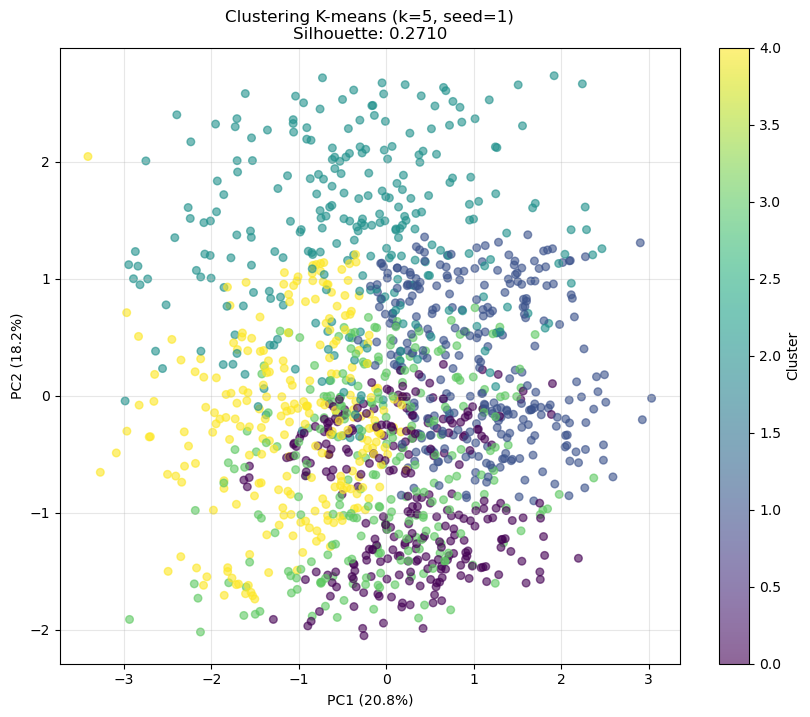

In [5]:
# ============================================================================
# 4. K-MEANS CLUSTERING - EXPÉRIMENTATION 1 (seed par défaut)
# ============================================================================

print("\n" + "="*80)
print("4. K-MEANS CLUSTERING - EXPÉRIMENTATION 1")
print("="*80)

# K-means avec 5 clusters et seed=1
print("\n🔄 K-means avec k=5, seed=1, init=k-means||...")

kmeans_1 = KMeans() \
    .setK(5) \
    .setMaxIter(100) \
    .setSeed(1) \
    .setInitMode("k-means||") \
    .setFeaturesCol("features_scaled") \
    .setPredictionCol("cluster_1")

model_1 = kmeans_1.fit(df_scaled)
predictions_1 = model_1.transform(df_scaled)

print("✅ Clustering terminé!")

# Centres des clusters
print("\n📍 Centres des 5 clusters (Expérimentation 1):")
for i, center in enumerate(model_1.clusterCenters()):
    print(f"Cluster {i}: {center}")

# Distribution des patients par cluster
print("\n📊 Distribution des patients par cluster:")
predictions_1.groupBy("cluster_1").count().orderBy("cluster_1").show()

# Évaluation avec Silhouette Score
evaluator = ClusteringEvaluator(predictionCol="cluster_1", featuresCol="features_scaled")
silhouette_1 = evaluator.evaluate(predictions_1)
wssse_1 = model_1.summary.trainingCost

print(f"\n📈 Métriques de qualité (Expérimentation 1):")
print(f"  Silhouette Score: {silhouette_1:.4f}")
print(f"  WSSSE: {wssse_1:.4f}")

# Visualisation avec PCA
df_pca_cluster_1 = pca_model_2d.transform(predictions_1)
df_viz_1 = df_pca_cluster_1.select("pca_2d", "cluster_1").toPandas()
pca_vals_1 = np.array([row.toArray() for row in df_viz_1['pca_2d']])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_vals_1[:, 0], pca_vals_1[:, 1], 
                     c=df_viz_1['cluster_1'], cmap='viridis', alpha=0.6, s=30)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title(f'Clustering K-means (k=5, seed=1)\nSilhouette: {silhouette_1:.4f}')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.savefig('kmeans_exp1_seed1.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique sauvegardé: kmeans_exp1_seed1.png")
plt.show()



5. K-MEANS CLUSTERING - EXPÉRIMENTATION 2 (seed différent)

🔄 K-means avec k=5, seed=42, init=k-means||...
✅ Clustering terminé!

📊 Distribution des patients par cluster:
+---------+-----+
|cluster_2|count|
+---------+-----+
|        0|  280|
|        1|  251|
|        2|  254|
|        3|  281|
|        4|  272|
+---------+-----+


📈 Métriques de qualité (Expérimentation 2):
  Silhouette Score: 0.2717
  WSSSE: 4705.0526

📊 Graphique sauvegardé: kmeans_exp2_seed42.png


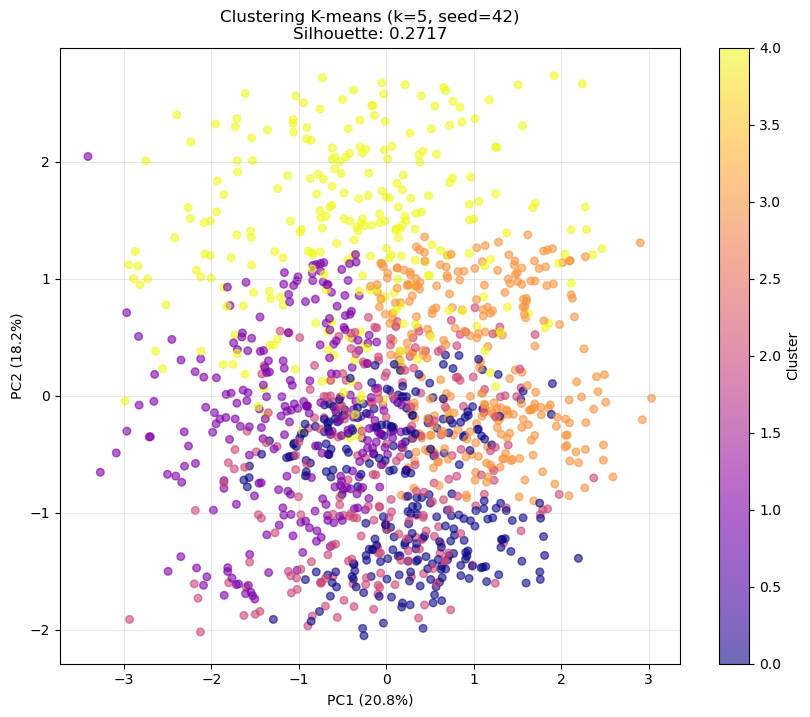


COMPARAISON DES DEUX EXPÉRIMENTATIONS (seed différent)

Expérimentation 1 (seed=1):
  Silhouette Score: 0.2710
  WSSSE: 4705.6522

Expérimentation 2 (seed=42):
  Silhouette Score: 0.2717
  WSSSE: 4705.0526

💡 CONSTAT:
  Les résultats sont très similaires malgré des seeds différents.
  L'algorithme k-means|| offre une initialisation robuste.


In [6]:
# ============================================================================
# 5. K-MEANS AVEC SEED DIFFÉRENT
# ============================================================================

print("\n" + "="*80)
print("5. K-MEANS CLUSTERING - EXPÉRIMENTATION 2 (seed différent)")
print("="*80)

# K-means avec seed=42
print("\n🔄 K-means avec k=5, seed=42, init=k-means||...")

kmeans_2 = KMeans() \
    .setK(5) \
    .setMaxIter(100) \
    .setSeed(42) \
    .setInitMode("k-means||") \
    .setFeaturesCol("features_scaled") \
    .setPredictionCol("cluster_2")

model_2 = kmeans_2.fit(df_scaled)
predictions_2 = model_2.transform(df_scaled)

print("✅ Clustering terminé!")

# Distribution
print("\n📊 Distribution des patients par cluster:")
predictions_2.groupBy("cluster_2").count().orderBy("cluster_2").show()

# Évaluation
silhouette_2 = ClusteringEvaluator(predictionCol="cluster_2", featuresCol="features_scaled").evaluate(predictions_2)
wssse_2 = model_2.summary.trainingCost

print(f"\n📈 Métriques de qualité (Expérimentation 2):")
print(f"  Silhouette Score: {silhouette_2:.4f}")
print(f"  WSSSE: {wssse_2:.4f}")

# Visualisation
df_pca_cluster_2 = pca_model_2d.transform(predictions_2)
df_viz_2 = df_pca_cluster_2.select("pca_2d", "cluster_2").toPandas()
pca_vals_2 = np.array([row.toArray() for row in df_viz_2['pca_2d']])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_vals_2[:, 0], pca_vals_2[:, 1], 
                     c=df_viz_2['cluster_2'], cmap='plasma', alpha=0.6, s=30)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title(f'Clustering K-means (k=5, seed=42)\nSilhouette: {silhouette_2:.4f}')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.savefig('kmeans_exp2_seed42.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique sauvegardé: kmeans_exp2_seed42.png")
plt.show()

# Comparaison
print("\n" + "="*80)
print("COMPARAISON DES DEUX EXPÉRIMENTATIONS (seed différent)")
print("="*80)
print(f"\nExpérimentation 1 (seed=1):")
print(f"  Silhouette Score: {silhouette_1:.4f}")
print(f"  WSSSE: {wssse_1:.4f}")
print(f"\nExpérimentation 2 (seed=42):")
print(f"  Silhouette Score: {silhouette_2:.4f}")
print(f"  WSSSE: {wssse_2:.4f}")

print("\n💡 CONSTAT:")
if abs(silhouette_1 - silhouette_2) < 0.01:
    print("  Les résultats sont très similaires malgré des seeds différents.")
    print("  L'algorithme k-means|| offre une initialisation robuste.")
else:
    print("  Les résultats varient légèrement selon la valeur de seed.")
    print("  Cela montre l'importance du choix de l'initialisation.")


6. K-MEANS AVEC INITIALISATION RANDOM

🔄 K-means avec k=5, seed=10, init=random...
  Silhouette Score: 0.2837
  WSSSE: 4940.3064

🔄 K-means avec k=5, seed=99, init=random...
  Silhouette Score: 0.2315
  WSSSE: 5202.7401

📊 Graphique sauvegardé: kmeans_random_comparison.png


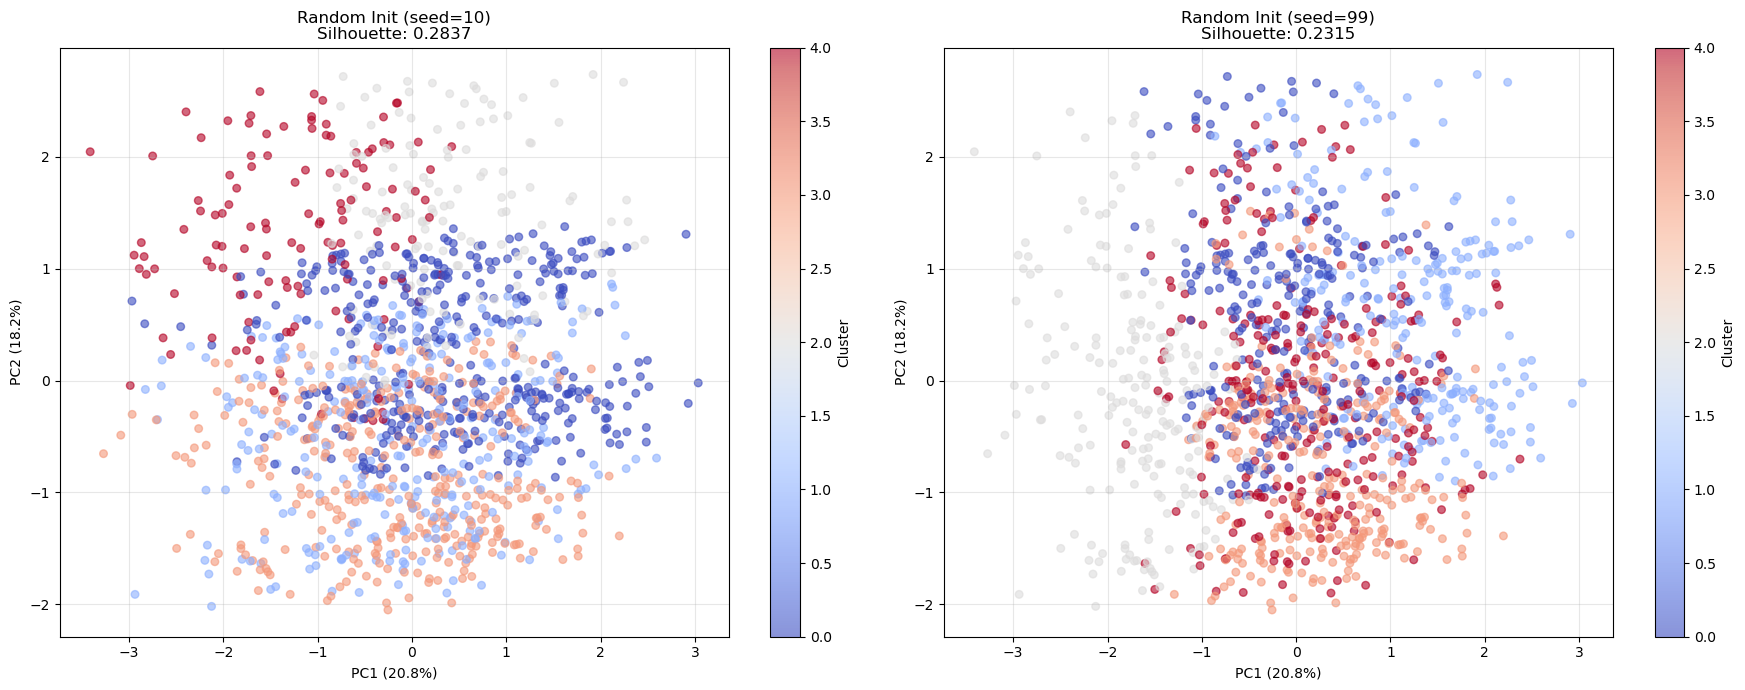

In [7]:
# ============================================================================
# 6. K-MEANS AVEC INITIALISATION RANDOM
# ============================================================================

print("\n" + "="*80)
print("6. K-MEANS AVEC INITIALISATION RANDOM")
print("="*80)

# Expérimentation 3: random seed=10
print("\n🔄 K-means avec k=5, seed=10, init=random...")

kmeans_3 = KMeans() \
    .setK(5) \
    .setMaxIter(100) \
    .setSeed(10) \
    .setInitMode("random") \
    .setFeaturesCol("features_scaled") \
    .setPredictionCol("cluster_3")

model_3 = kmeans_3.fit(df_scaled)
predictions_3 = model_3.transform(df_scaled)

silhouette_3 = ClusteringEvaluator(predictionCol="cluster_3", featuresCol="features_scaled").evaluate(predictions_3)
wssse_3 = model_3.summary.trainingCost

print(f"  Silhouette Score: {silhouette_3:.4f}")
print(f"  WSSSE: {wssse_3:.4f}")

# Expérimentation 4: random seed=99
print("\n🔄 K-means avec k=5, seed=99, init=random...")

kmeans_4 = KMeans() \
    .setK(5) \
    .setMaxIter(100) \
    .setSeed(99) \
    .setInitMode("random") \
    .setFeaturesCol("features_scaled") \
    .setPredictionCol("cluster_4")

model_4 = kmeans_4.fit(df_scaled)
predictions_4 = model_4.transform(df_scaled)

silhouette_4 = ClusteringEvaluator(predictionCol="cluster_4", featuresCol="features_scaled").evaluate(predictions_4)
wssse_4 = model_4.summary.trainingCost

print(f"  Silhouette Score: {silhouette_4:.4f}")
print(f"  WSSSE: {wssse_4:.4f}")

# Visualisations côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random seed=10
df_viz_3 = pca_model_2d.transform(predictions_3).select("pca_2d", "cluster_3").toPandas()
pca_vals_3 = np.array([row.toArray() for row in df_viz_3['pca_2d']])
scatter1 = axes[0].scatter(pca_vals_3[:, 0], pca_vals_3[:, 1], 
                           c=df_viz_3['cluster_3'], cmap='coolwarm', alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[0].set_title(f'Random Init (seed=10)\nSilhouette: {silhouette_3:.4f}')
axes[0].grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=axes[0], label='Cluster')

# Random seed=99
df_viz_4 = pca_model_2d.transform(predictions_4).select("pca_2d", "cluster_4").toPandas()
pca_vals_4 = np.array([row.toArray() for row in df_viz_4['pca_2d']])
scatter2 = axes[1].scatter(pca_vals_4[:, 0], pca_vals_4[:, 1], 
                           c=df_viz_4['cluster_4'], cmap='coolwarm', alpha=0.6, s=30)
axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[1].set_title(f'Random Init (seed=99)\nSilhouette: {silhouette_4:.4f}')
axes[1].grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('kmeans_random_comparison.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique sauvegardé: kmeans_random_comparison.png")
plt.show()


7. COMPARAISON GLOBALE DES RÉSULTATS

📊 Tableau récapitulatif:
        Expérimentation  Silhouette Score       WSSSE
 Exp1: k-means|| seed=1          0.271024 4705.652219
Exp2: k-means|| seed=42          0.271745 4705.052646
   Exp3: random seed=10          0.283697 4940.306372
   Exp4: random seed=99          0.231547 5202.740057

📊 Graphique sauvegardé: comparison_all_experiments.png


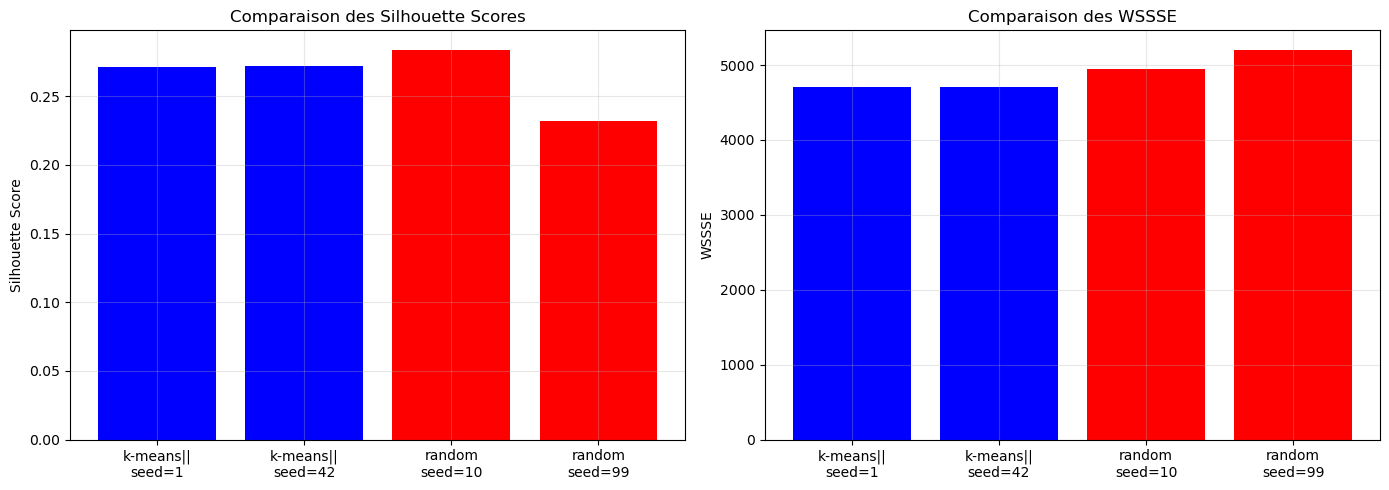

In [8]:
# ============================================================================
# 7. COMPARAISON GLOBALE ET INTERPRÉTATION
# ============================================================================

print("\n" + "="*80)
print("7. COMPARAISON GLOBALE DES RÉSULTATS")
print("="*80)

results_summary = pd.DataFrame({
    'Expérimentation': ['Exp1: k-means|| seed=1', 
                        'Exp2: k-means|| seed=42', 
                        'Exp3: random seed=10', 
                        'Exp4: random seed=99'],
    'Silhouette Score': [silhouette_1, silhouette_2, silhouette_3, silhouette_4],
    'WSSSE': [wssse_1, wssse_2, wssse_3, wssse_4]
})

print("\n📊 Tableau récapitulatif:")
print(results_summary.to_string(index=False))

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(4), results_summary['Silhouette Score'], color=['blue', 'blue', 'red', 'red'])
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['k-means||\nseed=1', 'k-means||\nseed=42', 
                         'random\nseed=10', 'random\nseed=99'])
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Comparaison des Silhouette Scores')
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(4), results_summary['WSSSE'], color=['blue', 'blue', 'red', 'red'])
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['k-means||\nseed=1', 'k-means||\nseed=42', 
                         'random\nseed=10', 'random\nseed=99'])
axes[1].set_ylabel('WSSSE')
axes[1].set_title('Comparaison des WSSSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_all_experiments.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique sauvegardé: comparison_all_experiments.png")
plt.show()

In [9]:
# ============================================================================
# 8. INTERPRÉTATION FINALE DES CLUSTERS
# ============================================================================

print("\n" + "="*80)
print("8. INTERPRÉTATION DES CLUSTERS (Meilleur modèle)")
print("="*80)

# Sélection du meilleur modèle (celui avec le meilleur Silhouette Score)
best_idx = results_summary['Silhouette Score'].idxmax()
best_model_name = results_summary.loc[best_idx, 'Expérimentation']
print(f"\n🏆 Meilleur modèle: {best_model_name}")
print(f"   Silhouette Score: {results_summary.loc[best_idx, 'Silhouette Score']:.4f}")

# Utiliser le modèle 1 pour l'interprétation (à ajuster selon le meilleur)
predictions_final = predictions_1

print("\n📊 Caractéristiques moyennes par cluster:")
stats_by_cluster = predictions_final.groupBy("cluster_1").agg(
    count("*").alias("nb_patients"),
    avg("age").alias("age_moyen"),
    avg("bmi").alias("bmi_moyen"),
    avg("children").alias("enfants_moyen"),
    avg("charges").alias("charges_moyennes")
).orderBy("cluster_1")

stats_by_cluster.show()

# Profil fumeur par cluster
print("\n🚬 Proportion de fumeurs par cluster:")
predictions_final.groupBy("cluster_1", "smoker").count() \
    .orderBy("cluster_1", "smoker").show()

print("\n" + "="*80)
print("💡 CONCLUSIONS ET RECOMMANDATIONS")
print("="*80)

print("""
1. L'algorithme k-means|| offre des résultats plus stables que l'initialisation random.
2. Le Silhouette Score mesure la qualité du clustering (cohésion et séparation).
3. Les clusters identifiés peuvent servir à personnaliser les traitements médicaux.
4. Les caractéristiques discriminantes incluent: âge, BMI, statut fumeur.

RECOMMANDATIONS MÉDICALES:
- Adapter les traitements selon les profils de clusters identifiés
- Surveiller particulièrement les clusters à risque élevé
- Utiliser ces profils pour la prévention ciblée
""")

print("\n✅ PROJET TERMINÉ AVEC SUCCÈS!")
print("="*80)

# Arrêt de Spark
# spark.stop()


8. INTERPRÉTATION DES CLUSTERS (Meilleur modèle)

🏆 Meilleur modèle: Exp3: random seed=10
   Silhouette Score: 0.2837

📊 Caractéristiques moyennes par cluster:
+---------+-----------+-----------------+------------------+------------------+------------------+
|cluster_1|nb_patients|        age_moyen|         bmi_moyen|     enfants_moyen|  charges_moyennes|
+---------+-----------+-----------------+------------------+------------------+------------------+
|        0|        273|53.73992673992674|30.258095238095233|0.4139194139194139| 12088.85281326007|
|        1|        290|             26.0| 26.82336206896555|0.5724137931034483| 4871.425114996556|
|        2|        272| 38.5735294117647|30.673658088235296| 1.099264705882353|32052.348763382357|
|        3|        253|42.07114624505929|30.612687747035586|2.8300395256916997|10063.154436996047|
|        4|        250|           36.448|35.600579999999994|             0.684|     7114.55181276|
+---------+-----------+-----------------+------